In [1]:
import numpy as np
import scipy.io as sio
import os
#from nltk.stem import WordNetLemmatizer
#from torchtext import vocab as Vocab
import collections
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from thinc.loss import CategoricalCrossentropy

from utils.utils import *
from IntraOp.model import BottleneckModel,CustomDataset

from tqdm import tqdm
from tensorly.decomposition import parafac
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

[nltk_data] Downloading package cmudict to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


In [2]:
data_folder='data'
patient='CTH'
all_patients=os.listdir(data_folder)
patient_folder_index=np.where([patient in s for s in all_patients])[0][0]
path=os.path.join(data_folder,all_patients[patient_folder_index],'pictureNaming_all_data.mat')
print(path)

all_data=sio.loadmat(path)['all_data']

data\2024-11-12 CTH\pictureNaming_all_data.mat


what is stored:
- HGA
- trial onset time
- green screen onset time
- trial offset time
- voice onset time
- voice offset time
- target
- answer

In [3]:
bin_size=100 # ms
#fs=all_data[0,-1][0][0] # Hz
fs=2000
data=all_data[:,0]
trial_onset=all_data[:,1] # in sec
green_screen_onset=all_data[:,2] # in sec
trial_offset=all_data[:,3] # in sec
voice_onset=all_data[:,4] # in sec
voice_offset=all_data[:,5] # in sec
target_label=all_data[:,6]
answer_label=all_data[:,7]
# for CTH
bad_channels=all_data[0,8][0]
bad_trials=all_data[0,9][0]
# bad_channels=[]
# bad_trials=[]

data=np.array([np.array([d for d in dt]) for dt in data]).swapaxes(1,2)[:,:,:] # n_trial x n_channels x n_time
data_binned=data.reshape(data.shape[0],data.shape[1],-1,bin_size).mean(axis=3)

n_trials=data.shape[0]
n_channels=data.shape[1]
n_time=data.shape[2]
n_bins=data_binned.shape[2]
adjusted_fs=int(fs/bin_size)

trial_onset=np.array([to[0][0] for to in trial_onset])
trial_offset=np.array([tof[0][0] for tof in trial_offset])
voice_onset=np.array([vo[0][0] if len(vo)>0 else np.nan for vo in voice_onset])
voice_offset=np.array([vof[0][0] if len(vof)>0 else np.nan for vof in voice_offset])
target_label=np.array([tl[0] for tl in target_label],dtype=object)
#answer_label=np.array([al[0][0][0] if len(al)>0 else '' for al in answer_label],dtype=object)

In [4]:
# here we remove the bad channels and bad trials
clean_data_binned=np.delete(np.delete(data_binned,bad_channels,axis=1),bad_trials,axis=0)
clean_data_binned=(clean_data_binned-np.mean(clean_data_binned,axis=1,keepdims=True))/np.std(clean_data_binned,axis=1,keepdims=True)
clean_data_binned=clean_data_binned[:,:,:]# manual inspection: there are 11 bad channels in the first grid. So 52 is the index to separate the grid
clean_voice_onset=np.delete(voice_onset,bad_trials)
clean_voice_offset=np.delete(voice_offset,bad_trials)
clean_target_label=np.delete(target_label,bad_trials)
clean_answer_label=np.delete(answer_label,bad_trials)

nan_trials=np.where(~np.isnan(clean_voice_onset))[0]
clean_data_binned=clean_data_binned[nan_trials]
clean_voice_onset=clean_voice_onset[nan_trials]
clean_voice_offset=clean_voice_offset[nan_trials]
clean_target_label=clean_target_label[nan_trials]
clean_answer_label=clean_answer_label[nan_trials]

n_clean_channels=clean_data_binned.shape[1]
n_clean_trials=clean_data_binned.shape[0]

In [ ]:
# since the picture naming has its own hand labeled category
df=pd.read_excel("../data/wordset picture naming expanded.xlsx")
df=pd.read_excel("../../data/wordset picture naming expanded.xlsx")
word_column=df.columns[0]
df.set_index(word_column,inplace=True)
df_filled=df.fillna(0)
df_filled = df_filled.apply(pd.to_numeric)
category_series = df_filled.idxmax(axis=1).reset_index()
# Rename columns
category_series.columns = [word_column, 'Category']

# Create the mapping
word_to_category_dict = dict(zip(category_series[word_column], category_series['Category']))

In [6]:
# temporary merge food and fruit to balance the class
word_category=[word_to_category_dict[word[0][:-1]] for word in clean_target_label]
#word_category=[w if w!='fruit'and w!='food (exclude fruit)' else 'food and fruit' for w in word_category ]
word_category=['nature' if (w =='nature') | (w=='animal') |(w=='body part')|(w=='fruit') else 'man made' for w in word_category]
collections.Counter(word_category)

Counter({'nature': 82, 'man made': 57})

0.5085360863309334


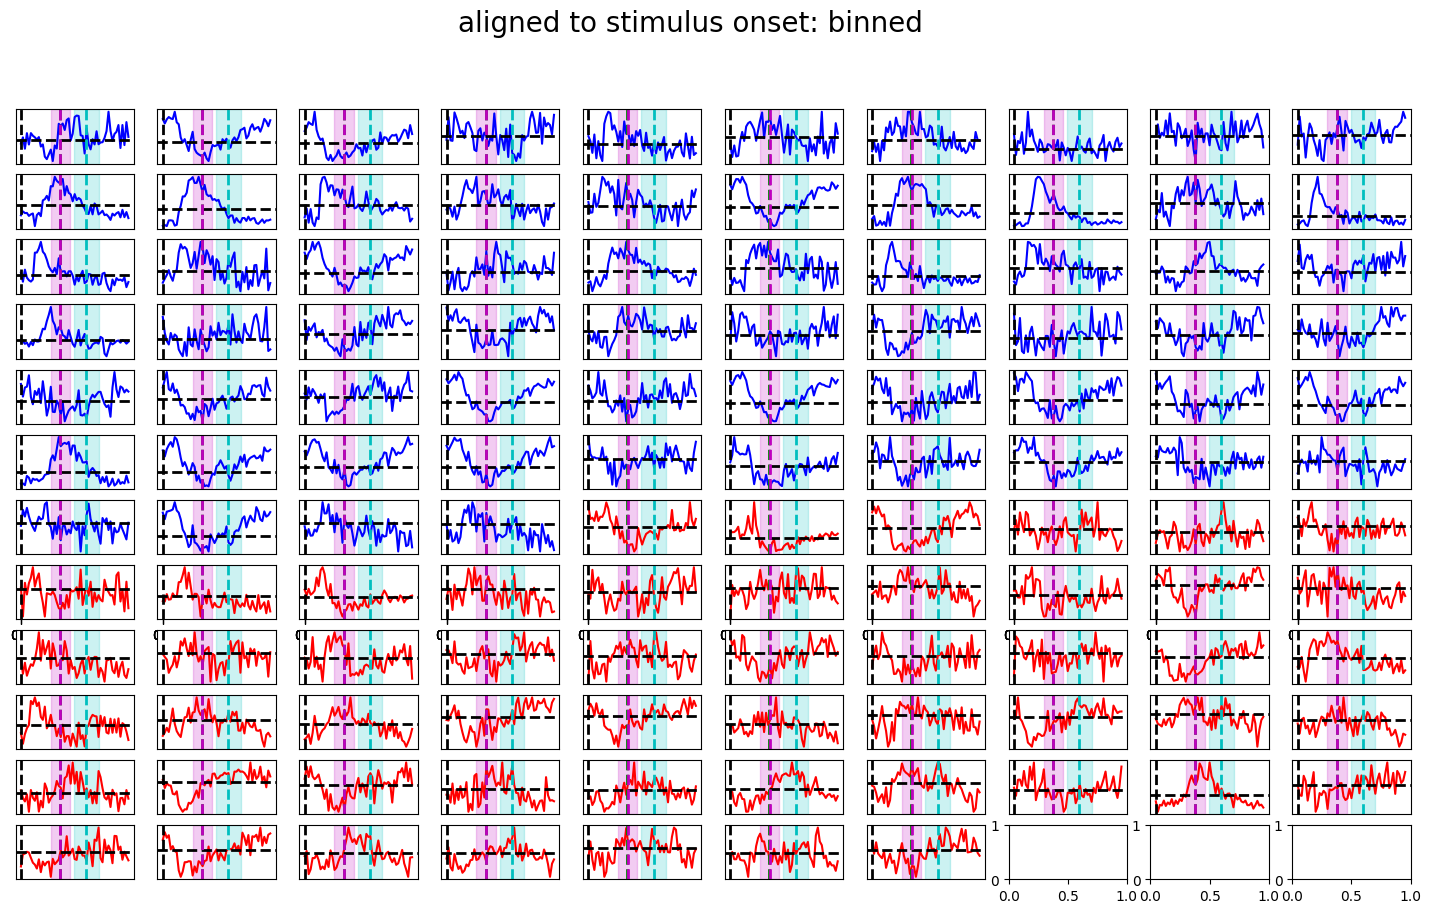

In [7]:
# here we are plotting trial averaged binned data
fig,ax=plt.subplots(n_clean_channels//10+1,10,figsize=(18,10))
for i in range(n_clean_channels):
    ax[i//10,i%10].plot(np.linspace(0,min(trial_offset),n_bins),clean_data_binned.mean(axis=0)[i],color='b' if i<64 else'r')
    ax[i//10,i%10].set_yticks([])
    #ax[i//10,i%10].set_ylim([-0.3,0.8])
    if i//10!=7:   
        ax[i//10,i%10].set_xticks([])
    else:
        ax[i//10,i%10].set_xticks(np.linspace(0,min(trial_onset),5), [f"{i:0.1f}" for i in np.linspace(0,min(trial_onset),5)])
        ax[i//10,i%10].set_xlabel("time (s)")
    
    ax[i//10,i%10].axvspan(np.nanmean(clean_voice_onset) - np.nanstd(clean_voice_onset), np.nanmean(clean_voice_onset) + np.nanstd(clean_voice_onset), color='m', alpha=0.2)
    ax[i//10,i%10].axvspan(np.nanmean(clean_voice_offset) - np.nanstd(clean_voice_offset), np.nanmean(clean_voice_offset) + np.nanstd(clean_voice_offset), color='c', alpha=0.2)
    ax[i//10,i%10].axhline(0, color='k', linestyle='--', linewidth=2)
    ax[i//10,i%10].axvline(0, color='k', linestyle='--', linewidth=2)
    ax[i//10,i%10].axvline(green_screen_onset[0], color='g', linestyle='--', linewidth=2)
    ax[i//10,i%10].axvline(np.nanmean(clean_voice_onset), color='m', linestyle='--', linewidth=2)
    ax[i//10,i%10].axvline(np.nanmean(clean_voice_offset), color='c', linestyle='--', linewidth=2)
print(np.nanmean(clean_voice_onset)-0.5)
plt.suptitle("aligned to stimulus onset: binned",fontsize=20)
plt.show()

In [8]:
data_binned_voice_onset=[]
back=np.nanmin(clean_voice_onset)
forward=np.nanmin(trial_offset[0]-clean_voice_onset)
for i in range(n_clean_trials):
    trial=clean_data_binned[i]
    #if answered_lexeme[i]!='':
    truncated=trial[:,int((clean_voice_onset[i]-back)*adjusted_fs):int((clean_voice_onset[i]+forward)*adjusted_fs)]
    data_binned_voice_onset.append(truncated)
trial_min_length=np.min([i.shape[1] for i in data_binned_voice_onset])
data_binned_voice_onset=np.array([i[:,:trial_min_length] for i in data_binned_voice_onset])


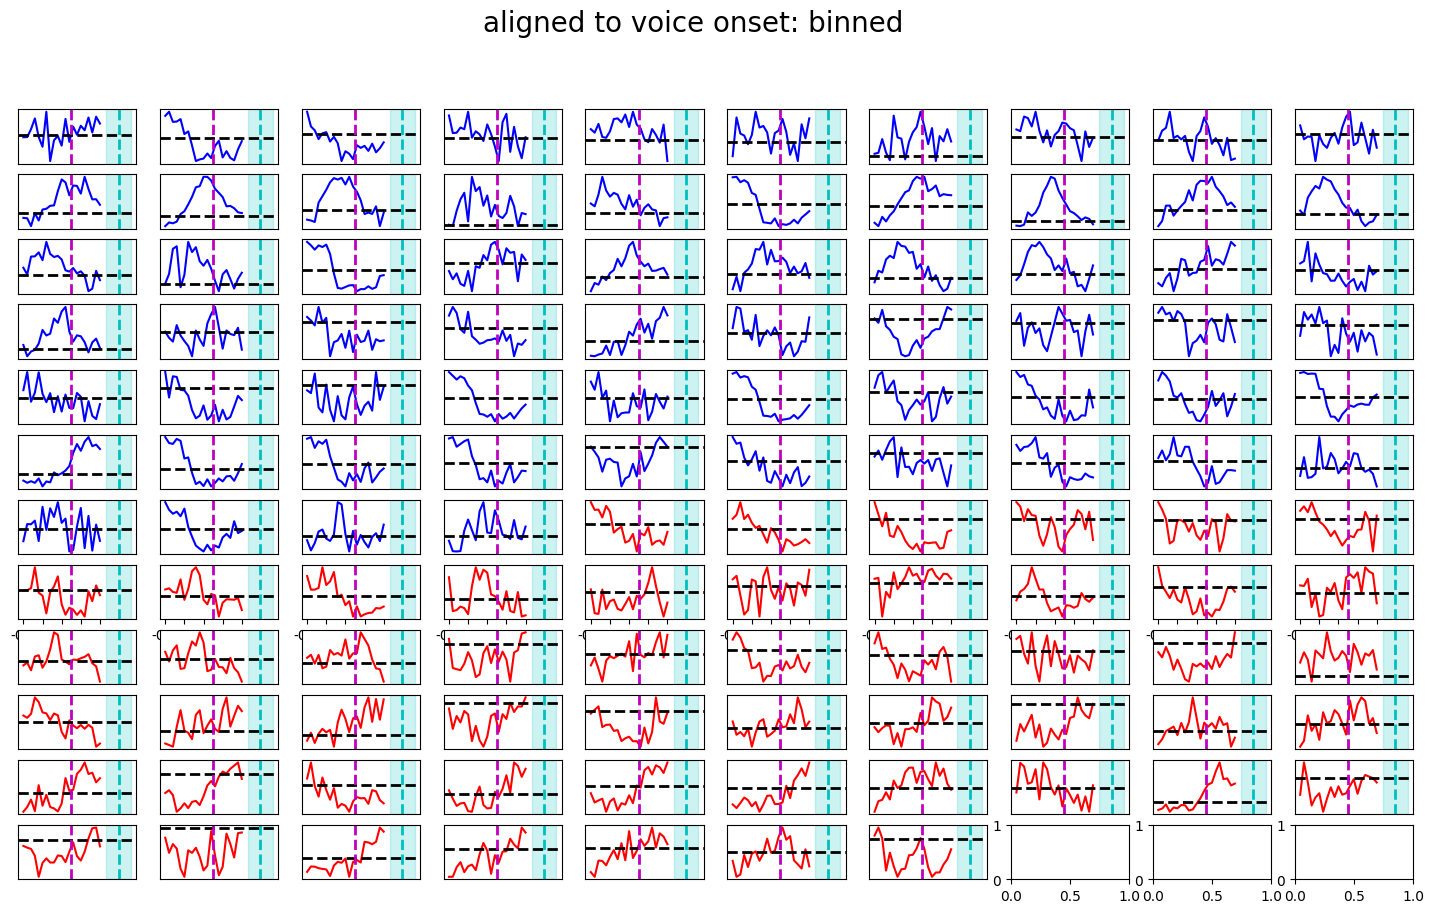

In [9]:
# here we are plotting trial averaged binned data
fig,ax=plt.subplots(n_clean_channels//10+1,10,figsize=(18,10))
for i in range(n_clean_channels):
    ax[i//10,i%10].plot(np.linspace(-back,forward,trial_min_length),data_binned_voice_onset.mean(axis=0)[i],color='b' if i<64 else'r')
    ax[i//10,i%10].set_yticks([])
    #ax[i//10,i%10].set_ylim([-0.3,1.5])
    if i//10!=7:   
        ax[i//10,i%10].set_xticks([])
    else:
        ax[i//10,i%10].set_xticks(np.linspace(-back,forward,5), [f"{i:0.1f}" for i in np.linspace(-back,forward,5)])
        ax[i//10,i%10].set_xlabel("time (s)")
    
    ax[i//10,i%10].axvspan(np.nanmean(clean_voice_offset-clean_voice_onset) - np.nanstd(clean_voice_offset-clean_voice_onset), np.nanmean(clean_voice_offset-clean_voice_onset) + np.nanstd(clean_voice_offset-clean_voice_onset), color='c', alpha=0.2)
    ax[i//10,i%10].axhline(0, color='k', linestyle='--', linewidth=2)
    ax[i//10,i%10].axvline(0, color='m', linestyle='--', linewidth=2)
    ax[i//10,i%10].axvline(np.nanmean(clean_voice_offset-clean_voice_onset), color='c', linestyle='--', linewidth=2)

plt.suptitle("aligned to voice onset: binned",fontsize=20)
plt.show()

In [10]:
def reformat_now(data, bins_per_feature):
    reformatted_data = []
    for i in range(data.shape[1]):
        reformatted = data[:, i - np.minimum(i, bins_per_feature - 1):i + 1, :]
        reformatted_data.append(reformatted)
    return reformatted_data

# Doing semantic category classification using Bottleneck model

In [11]:
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch

In [12]:
# prepare the data and labels
n_bins_history=5
#data_to_use=np.array(data_binned_voice_onset).swapaxes(1,2)
data_to_use=np.array(clean_data_binned).swapaxes(1,2)

# prepare the data
X_to_use=reformat(data_to_use,n_bins_history+1)
label_to_index={label: idx for idx, label in enumerate(set(word_category))}
labels_to_use=torch.tensor([label_to_index[label] for label in word_category])
n_classes=len(np.unique(labels_to_use))-1 # for binary classification we are using only 1 class. This is for the BCEWithLogits function

# specify the hyperparameters for the model
n_bottleneck=10
batch_size=130
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device='cpu'

Start training

In [13]:
# train a model for each time point
all_train_loss=[]
all_test_loss=[]
all_test_accuracy=[] 

best_test_accuracy=[]

for i in range(len(X_to_use)):
    if 1:   # looking into the time point where the highest decoding accuracy should have occurred 
        n_features=X_to_use[i].shape[1]
        X_train, X_test, y_train, y_test = train_test_split(X_to_use[i], labels_to_use, test_size=0.4)
        
        # prepare the model
        model=BottleneckModel(n_features,n_classes,n_bottleneck,dropout_rate=0.2).to(device)
        
        #Loss function and optimizer
        #criterion=nn.CrossEntropyLoss()
        criterion = nn.BCEWithLogitsLoss()
        optimizer=optim.Adam(model.parameters(),lr=0.0005)
        
        # prepare the dataset
        dataset_train = CustomDataset(X_train.astype(np.float32), y_train)
        data_loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True) 
        dataset_test = CustomDataset(X_test.astype(np.float32), y_test)
        data_loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False) 
        
        num_epochs = 100
        train_loss = []
        test_loss = []
        test_accuracies=[]
        for epoch in tqdm(range(num_epochs)):
            for i, (batch_data, batch_labels) in enumerate(data_loader_train):
                model.train()
                running_loss = 0.0
                for inputs, labels in data_loader_train:
                    inputs=inputs.to(device)
                    labels = labels.to(device)
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels[:,None].float())
                    
                    # back propagation
                    loss.backward()
                    optimizer.step()
                    running_loss += loss.item()
                
                train_loss.append(running_loss / len(data_loader_train))
                
                # Test loop
                model.eval()
                val_loss = 0.0
                correct = 0
                total = 0
                with torch.no_grad():
                    for inputs, labels in data_loader_test:
                        inputs=inputs.to(device)
                        labels = labels.to(device)
                        
                        outputs = model(inputs)
                        loss = criterion(outputs, labels[:,None].float())
                        val_loss += loss.item()
                        #_, predicted = torch.max(outputs, 1)
                        predicted=(torch.sigmoid(outputs) > 0.5).float()
                        correct += (predicted == labels).sum().item()
                        total += labels.size(0)
                
                test_loss.append(val_loss / len(data_loader_test))
                test_accuracies.append(correct / total)
                
        all_train_loss.append(np.array(train_loss))
        all_test_loss.append(np.array(test_loss))
        all_test_accuracy.append(np.array(test_accuracies))
        best_test_accuracy.append(max(test_accuracies))
all_test_accuracy=np.array(all_test_accuracy)
all_test_loss=np.array(all_test_loss)
all_train_loss=np.array(all_train_loss)
best_test_accuracy=np.array(best_test_accuracy)

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 100/100 [00:00<00:00, 268.51it/s]


<Figure size 640x480 with 0 Axes>

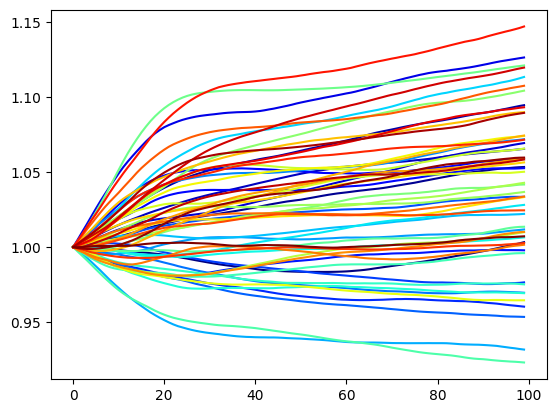

In [14]:
plt.figure()
#plt.plot(all_test_accuracy[:,-1])
#plt.fill_between(np.arange(len(all_test_accuracy)),
#                 all_test_accuracy.mean(1)-all_test_accuracy.std(1),
#                 all_test_accuracy.mean(1)+all_test_accuracy.std(1),alpha=0.2)
plt.figure()
#plt.plot(all_train_loss[24,:],color='magenta',label='Train loss')
#plt.plot(all_test_loss[1,:],color='cyan',label='Test loss')
colors = plt.cm.jet(np.linspace(0,1,all_test_loss.shape[0]))
for i in range(all_test_loss.shape[0]):
    plt.plot(all_test_loss[i]/all_test_loss[i,0],color=colors[i])
#plt.legend()
plt.show()

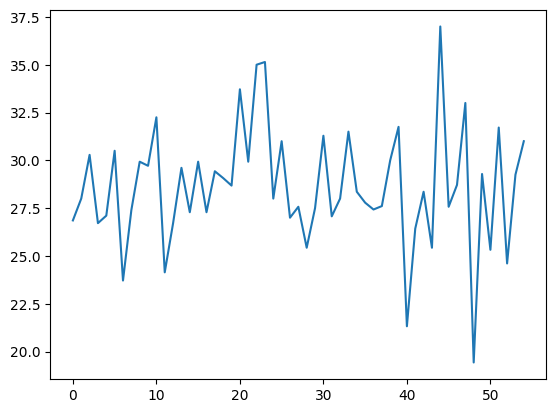

In [15]:
plt.plot(best_test_accuracy)
plt.show()